### Preprocessing

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

In [16]:
# fetch dataset 
multivariate_gait_data = fetch_ucirepo(id=760)

In [17]:
# store data in two formats
long = multivariate_gait_data.data.features
wide = long.pivot_table(index=["subject", "replication", "time", "condition"], columns=["leg", "joint"])

In [18]:
# randomly select training/testing subjects (80/20 split)
# split data by subjects to avoid data leakage
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

In [19]:
# split training/testing data (wide)
train_wide = wide[wide.index.get_level_values("subject").isin(train_subjects)]
test_wide = wide[wide.index.get_level_values("subject").isin(test_subjects)]

In [20]:
def engineer_features(df):
    """ Performs feature engineering to get raw data stats, differential data 
    stats, and stats by quarter """
    # select stats to use as features
    stats = ["mean", "std", "skew", "min", "max"]

    # raw stats
    raw_stats = df.groupby(["subject", "replication", "condition"]).agg(stats)

    # differential stats
    raw_diffs = df.groupby(["subject", "replication", "condition"]).diff().dropna()
    diffs_stats = raw_diffs.groupby(["subject", "replication", "condition"]).agg(stats)

    # raw and differential stats
    full_stats = pd.concat([raw_stats, diffs_stats], axis=1)

    # quarter stats
    quarter_df = df.copy()
    quarter_df["quarter"] = pd.cut(
        quarter_df.index.get_level_values("time"),
        bins=[0, 25, 50, 75, 100],
        labels=["q1", "q2", "q3", "q4"],
        include_lowest=True
        )
    quarter_stats = quarter_df.groupby(["subject", "replication", "condition", "quarter"]).agg(stats)

    return raw_stats, diffs_stats, full_stats, quarter_stats

In [21]:
# each variable stores (raw_stats, diffs_stats, full_stats, quarter_stats)
train_wide_stats = engineer_features(train_wide)
test_wide_stats = engineer_features(test_wide)

In [22]:
def feature_labels_split_wide(df):
    """ Split a wide df into features and labels """
    X = df.droplevel("condition")
    y = pd.Series(df.index.get_level_values("condition"))
    return X, y

### SVM (with PCA for dimensionality reduction)
*Attempt at using our own feature-engineered tabular data*

In [23]:
# get full stats data
train_full_stats = train_wide_stats[2]
test_full_stats = test_wide_stats[2]

# split into features and labels
X_train_full, y_train_full = feature_labels_split_wide(train_full_stats)
X_test_full, y_test_full = feature_labels_split_wide(test_full_stats)

In [24]:
# scale the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test_full = scaler.transform(X_test_full)

Text(0.5, 1.0, 'Number of PCA Components vs. Explained Variance')

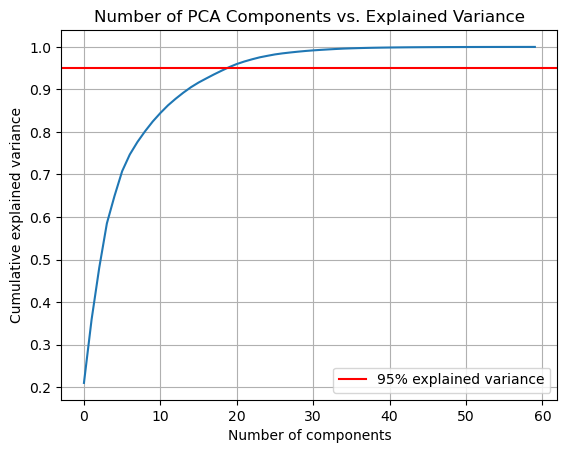

In [25]:
# plot a graph to figure out the optimal number of PCA components
pca = PCA().fit(X_train_full)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="red", label="95% explained variance")
plt.legend()
plt.grid(True)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Number of PCA Components vs. Explained Variance")

In [26]:
# identify the specific number of components
opt_n = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95)
print(f"Optimal number of PCA components: {opt_n}")

Optimal number of PCA components: 19


In [27]:
# apply PCA
pca = PCA(n_components=opt_n)
X_train_full_pca = pca.fit_transform(X_train_full)
X_test_full_pca = pca.transform(X_test_full)

In [30]:
svm = SVC(probability=True)
svm.fit(X_train_full_pca, y_train_full)
predicted = svm.predict(X_test_full_pca)
predicted_proba = svm.predict_proba(X_test_full_pca)
print(classification_report(y_test_full, predicted))
print(f"AUC: {roc_auc_score(y_test_full, predicted_proba, multi_class='ovr')}")


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

AUC: 1.0
